# Support Vector Machines

A [**Support Vector Machine**](https://link.springer.com/article/10.1007/BF00994018) (SVM) is a powerful and versatile algorithm, capable of **performing linear and nonlinear classification, regression, and even outlier detection**. SVMs are particularly well suited for classification of **complex small-medium-sized** datasets.

## Margins

Imagine we have a dataset of training points, where each point is in one of two classes:

$\displaystyle L = \{x_i, y_i\} \quad \text{where} \quad x_i \in \mathbb{R}^D \quad \text{and} \quad y_i \in \{-1, 1\} \quad i=1,..,m$

We assume the data is linearly separable, meaning that there exists a hyperplane that separates the two classes. Mathematically, the hyperplane $H$ can be described by the equation:

$\displaystyle  H = \left\{ x : w^Tx+b=0 \right\} $

where $w$ is the normal vector to the hyperplane and $b$ is the bias term. We can write a classifier as:

$\displaystyle h_{w,b}(x) = g(w^tx+b)$

where $g$ is the sign function: $g(z) = 1$ if $z \geq 0$ and $g(z) = -1$ otherwise. 

Differently from the linear model discussion, here we use the notion $(w,b)$ instead of $\theta$ to explicitly treat the intercept term separately from the other parameters.

Consider a point far from the hyperplane, in that case the classifier will be very confident about its classification. On the other hand, a point close to the hyperplane will be classified with less confidence. So, we can define the **margin**  as the **distance of a point from the hyperplane**:

![](images/margins.png)

How we can calculate the margin? Consider some point $(x, y)$ and let $d$ the vector from $H$ to the point:

![](images/distance.png)

we can express the distance (margin) as the length (norm) of the vector $d$ and this vector is equal to the difference between the point $x$ and the projection of $x^p$ onto the hyperplane $H$:

$\displaystyle |d| = \sqrt{d^Td}$

$\displaystyle d = x - x^p$

however, since $d$ is parallel to the normal vector $w$, there exists a scalar $\alpha$ such that 

$\displaystyle d = \alpha w$ 

moreover, $x^p$ is on the hyperplane, so $w^Tx^p+b=0$. Then, composing those expressions we have:

$\displaystyle w^T(x-\alpha w)+b=0$

and we can solve for $\alpha$:

$\displaystyle \alpha = \frac{w^Tx+b}{w^tw}$

and this allows us to express the distance as:

$\displaystyle |d| = \sqrt{d^Td} = \sqrt{\alpha^2 w^Tw} = \sqrt{\left(\frac{w^Tx+b}{w^Tw}\right)^2 w^T w} = \frac{|w^Tx+b|}{\sqrt{w^Tw}} = \frac{|w^Tx+b|}{|w|}$

So we can define the margin $\gamma^{(i)}$ for a point $x^{(i)}$ as

$\displaystyle \gamma^{(i)}(w,b) = \frac{|w^Tx^{(i)}+b|}{|w|}$

**A large value of the margin represent a confident and correct prediction**.

Notice that the margin is invariant to the scale of the parameters $w$ and $b$, because we can multiply both by a constant and the margin will remain the same.

Considering all the example in the training set $L$, we can define the **margin of the hyperplane** as the smallest of the margins on all the points:

$\displaystyle \gamma (w,b) = \min_{i=1,...,m} \gamma^{(i)}(w,b)$

## Optimal Margin Classifier

We can have **many possible hyperplanes that could separate the classes**. The goal of the SVM is to find the hyperplane $(w,b)$ that maximizes the margin (**maximum margin hyperplane**), since this would reflect a very confident set of predictions and give us a classifier that separates positive and negative training example with a large gap (margin):

![](images/maximum-margin-hyperplane.png)

So we can pose the following optimization problem: the objective is to maximize the margin, subject to the constraint that all points are correctly classified (lie on the correct side of the hyperplane). This can be expressed as:

$\displaystyle \Bigg \{ \begin{matrix} \max_{w,b} \gamma(w,b) \hspace{130 pt}   \\
\text{s.t.} \quad y^{(i)}(w^Tx^{(i)}+b) \geq 0 \quad \text{for} \quad i=1,...,m \end{matrix}$

Plugging the definition of the margin, we have:

$\displaystyle \max_{w,b} \min_{i=1,...,m} \gamma^{(i)}(w,b) = \max_{w,b} \frac{1}{|w|} \min_{i=1,...,m} |w^Tx^{(i)}+b|$

Because the hyperplane is invariant to the scale of the parameters, we can fix the scale of $(w,b)$ anyway we want, se we can be clever an choose it such that:

$\displaystyle \min_{i=1,...,m} |w^Tx^{(i)}+b| = 1$

then the objective becomes:

$\displaystyle \max_{w,b} \frac{1}{|w|} \min_{i=1,...,m} |w^Tx^{(i)}+b| = \max_{w,b} \frac{1}{|w|} = \min_{w,b} |w| = \min_{w,b} w^Tw$ 

and the constrains become:

$\displaystyle \text{s.t.} \quad y^{(i)}(w^Tx^{(i)}+b) \geq 0 \quad \text{for} \quad i=1,...,m$

$\displaystyle \quad \quad \min_{i=1,...,m} |w^Tx^{(i)}+b| = 1$

The two constraints can be combined into a single one e the final optimization problem becomes:

$\displaystyle \Bigg \{ \begin{matrix} \min_{w,b} w^Tw \hspace{140 pt}   \\
\text{s.t.} \quad y^{(i)}(w^Tx^{(i)}+b) \geq 1 \quad \text{for} \quad i=1,...,m \end{matrix}$

For the optimal (w,b) pair, some point will have a margin of exactly 1, and are called **support vectors**. They are special because define the maximum margin of the hyperplane to the data set and they therefore **determine the shape of the hyperplane**. If we were to move one of them and retrain the SVM, the resulting hyperplane would change. The opposite is the case for non-support vectors (provided we don't move them too much, or they would turn into support vectors themselves).

This problem is an optimization problem with a quadratic objective function and linear constraints, called **primal problem**. We can solve it using the method of **Lagrange multipliers**. Consider a problem of the following form:

$\displaystyle \Bigg \{ \begin{matrix} \min_{\omega} f(\omega) \hspace{100 pt}   \\
\text{s.t.} \quad h_i(\omega) = 0 \quad \text{for} \quad i=1,...,l \end{matrix}$

We can define the **Lagrangian** as:

$\displaystyle  \mathcal{\omega, \beta}


We can try this idea with the iris dataset:

In [147]:
from sklearn import datasets
iris = datasets.load_iris()

In [148]:
X = iris["data"][:, (2, 3)]  # petal length, petal width
y = iris["target"]

setosa_or_versicolor = (y == 0) | (y == 1)
X = X[setosa_or_versicolor]
y = y[setosa_or_versicolor]

The two classes can clearly be separated easily with a straight line (they are **linearly separable**):

In [149]:
import numpy as np

x0 = np.linspace(0, 5.5, 200)

pred_1 = 5*x0 - 20
pred_2 = x0 - 1.8
pred_3 = 0.1 * x0 + 0.5

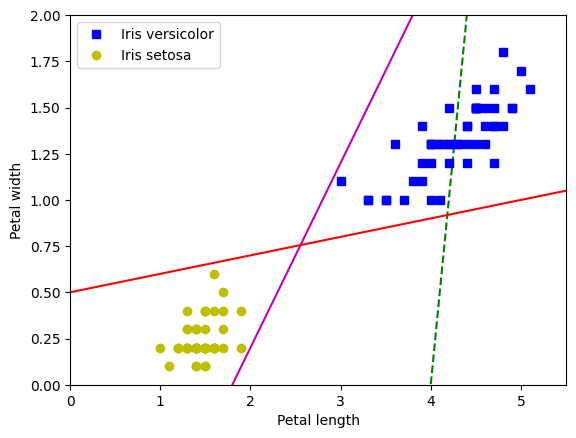

In [150]:
import matplotlib.pyplot as plt

plt.plot(x0, pred_1, "g--")
plt.plot(x0, pred_2, "m-")
plt.plot(x0, pred_3, "r-")

plt.plot(X[:, 0][y==1], X[:, 1][y==1], "bs", label="Iris versicolor")
plt.plot(X[:, 0][y==0], X[:, 1][y==0], "yo", label="Iris setosa")

plt.xlabel("Petal length")
plt.ylabel("Petal width")
plt.legend(loc="upper left")
plt.axis([0, 5.5, 0, 2])

plt.show()

The plot shows the decision boundaries of three possible linear classifiers. The model whose decision boundary is represented by the dashed line is so bad that it does not even separate the classes properly. The other two models work perfectly on this training set, but their decision boundaries come so close to the instances that these models will probably not perform as well on new instances. SMV finds the line that not only separates the two classes but also stays as far away from the closest training instances as possible:

In [151]:
from sklearn.svm import SVC

svm_clf = SVC(kernel='linear', C=10**9, probability=True)
svm_clf.fit(X, y)

SVC(C=1000000000, kernel='linear', probability=True)

In [152]:
def plot_svm_decision_boundary(svm_clf, xmin, xmax, xlable, ylabel):

    x = np.linspace(xmin, xmax, 200)

    w = svm_clf.coef_[0]
    b = svm_clf.intercept_[0]
    
    decision_boundary = -w[0]/w[1] * x - b/w[1]

    margin = 1/w[1]
    gutter_up = decision_boundary + margin
    gutter_down = decision_boundary - margin

    svs = svm_clf.support_vectors_
    
    plt.scatter(svs[:, 0], svs[:, 1], s=180, facecolors='#FFAAAA')
    
    plt.plot(x, decision_boundary, "k-")
    plt.plot(x, gutter_up, "k--")
    plt.plot(x, gutter_down, "k--")

    plt.xlabel(xlable)
    plt.ylabel(ylabel)

(0.0, 5.5, 0.0, 2.0)

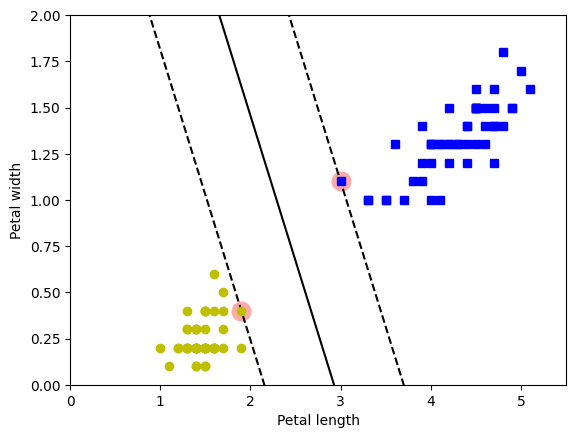

In [153]:
plot_svm_decision_boundary(svm_clf, 0, 5.5, "Petal length", "Petal width")

plt.plot(X[:, 0][y==1], X[:, 1][y==1], "bs")
plt.plot(X[:, 0][y==0], X[:, 1][y==0], "yo")
plt.axis([0, 5.5, 0, 2])

Notice that adding more training instances “off the street” will not affect the decision boundary at all: it is fully determined (or supported) by the  support vectors. If we strictly impose that all instances must be "off the street" and on the right side, this is called **hard margin classification**. There is a major issue with this approach: **it only works if the data is linearly separable**. If we add just one additional outlier that makes th two classes not linearly separable, there is no possible hard margin:

In [154]:
X_outlier = np.array([[3.4, 1.3]])
y_outlier = np.array([0])

Xo = np.concatenate([X, X_outlier], axis=0)
yo = np.concatenate([y, y_outlier], axis=0)

In [155]:
svm_clf = SVC(kernel="linear", C=10**9)
svm_clf.fit(Xo, yo)

SVC(C=1000000000, kernel='linear')

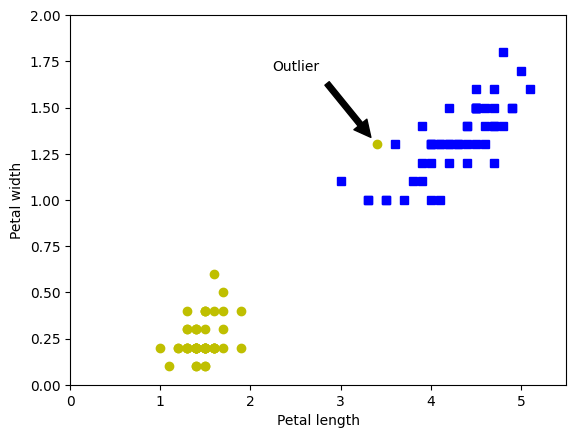

In [156]:
plt.plot(Xo[:, 0][yo==1], Xo[:, 1][yo==1], "bs")
plt.plot(Xo[:, 0][yo==0], Xo[:, 1][yo==0], "yo")

plt.xlabel("Petal length")
plt.ylabel("Petal width")

plt.annotate("Outlier",
             xy=(X_outlier[0][0], X_outlier[0][1]),
             xytext=(2.5, 1.7),
             ha="center",
             arrowprops=dict(facecolor='black', shrink=0.1)
             )
plt.axis([0, 5.5, 0, 2])

plt.show()

Moreover, **it is sensitive to outliers**, also if we add an outlier inside the region, the decision boundary ends up very different and it will probably not generalize as well:

In [157]:
X_outlier = np.array([[3.2, 0.8]])
y_outlier = np.array([0])

Xo = np.concatenate([X, X_outlier], axis=0)
yo = np.concatenate([y, y_outlier], axis=0)

In [158]:
svm_clf = SVC(kernel="linear", C=10**9)
svm_clf.fit(Xo, yo)

SVC(C=1000000000, kernel='linear')

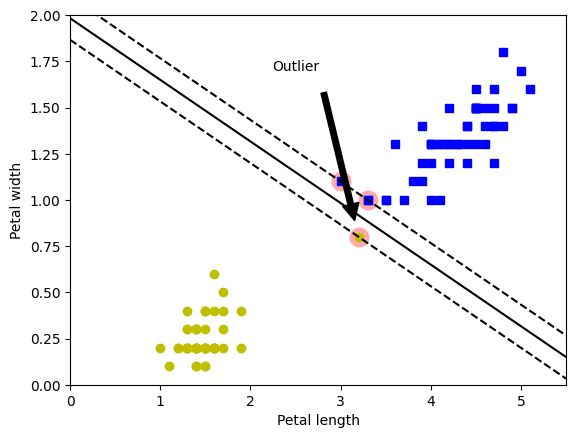

In [162]:
plt.plot(Xo[:, 0][yo==1], Xo[:, 1][yo==1], "bs")
plt.plot(Xo[:, 0][yo==0], Xo[:, 1][yo==0], "yo")

plt.xlabel("Petal length")
plt.ylabel("Petal width")

plt.annotate("Outlier",
             xy=(X_outlier[0][0], X_outlier[0][1]),
             xytext=(2.5, 1.7),
             ha="center",
             arrowprops=dict(facecolor='black', shrink=0.1)
             )
plt.axis([0, 5.5, 0, 2])

plot_svm_decision_boundary(svm_clf, 0, 5.5, "Petal length", "Petal width")

plt.show()

To avoid these issues, we can use **a more flexible model**. The objective is to find **a good balance between keeping the street as large as possible and limiting the margin violations** (instances that end up in the middle of the street or even on the wrong side). This is called **soft margin classification**. When creating an SVM model, we can specify the regularization ** hyperparameter C in order to decide this balance**. Reducing C makes the street larger, but it also leads to more margin violations. In other words, reducing C results in more instances supporting the street, so there’s less risk of overfitting. But if we reduce it too much, then the model ends up underfitting. Let's try with the Iris virginica:

In [163]:
X = iris["data"][:, (2, 3)]  # petal length, petal width
y = (iris["target"] == 2).astype(np.float64)  # iris virginica

In [164]:
svm_clf1 = SVC(kernel="linear", C=1)
svm_clf1.fit(X, y)

SVC(C=1, kernel='linear')

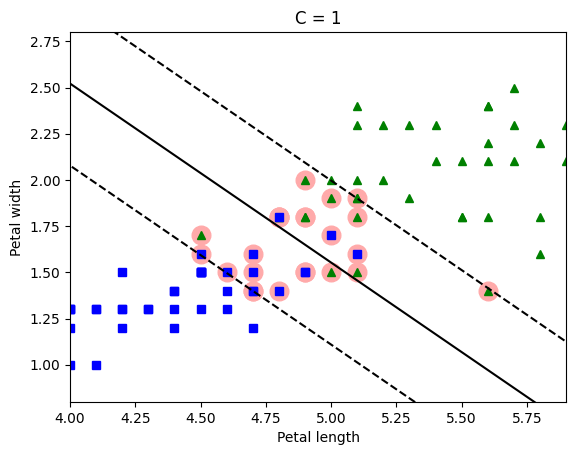

In [165]:
plt.plot(X[:, 0][y==1], X[:, 1][y==1], "g^")
plt.plot(X[:, 0][y==0], X[:, 1][y==0], "bs")
plt.title("C = {}".format(svm_clf1.C))
plt.axis([4, 5.9, 0.8, 2.8])
plot_svm_decision_boundary(svm_clf1, 0, 8, "Petal length", "Petal width")

In [166]:
svm_clf2 = SVC(kernel="linear", C=100)
svm_clf2.fit(X, y)

SVC(C=100, kernel='linear')

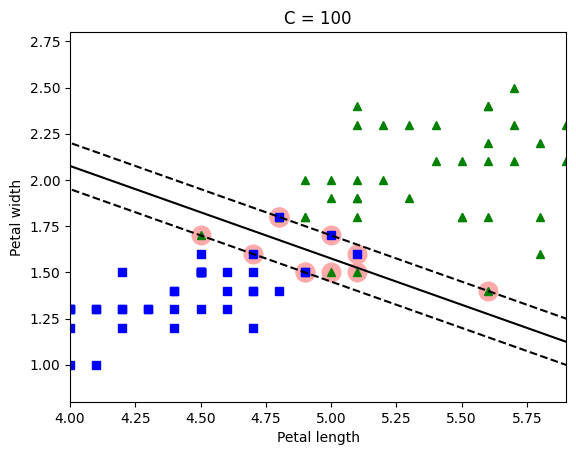

In [167]:
plt.plot(X[:, 0][y==1], X[:, 1][y==1], "g^")
plt.plot(X[:, 0][y==0], X[:, 1][y==0], "bs")
plt.title("C = {}".format(svm_clf2.C))
plt.axis([4, 5.9, 0.8, 2.8])
plot_svm_decision_boundary(svm_clf2, 0, 8, "Petal length", "Petal width")

Margin violations are bad. If our SVM model is overfitting, we can try regularizing it by reducing C.

## Nonlinear Classification

Although linear SVM classifiers are efficient and often work surprisingly well, many datasets are not even close to being linearly separable. One approach to handling nonlinear datasets is to add more features, such as polynomial features, in some cases this can result in a linearly separable dataset. As an example, consider a simple dataset with just one feature, but not linearly separable: 

In [168]:
X_simple = np.linspace(-4, 4, 9).reshape(-1, 1)
y_simple = np.array([0, 0, 1, 1, 1, 1, 1, 0, 0])

(-4.5, 4.5, -0.2, 0.2)

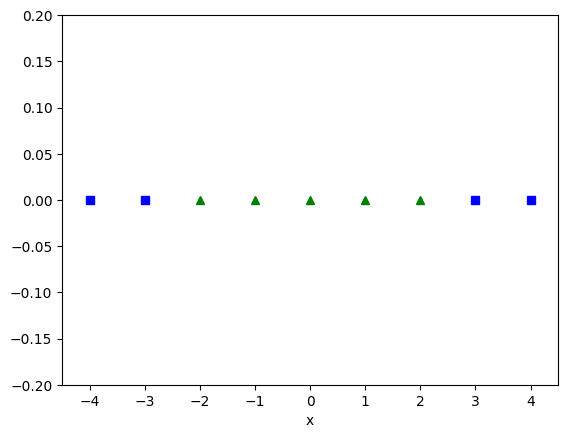

In [169]:
plt.plot(X_simple[:, 0][y_simple==0], np.zeros(4), "bs")
plt.plot(X_simple[:, 0][y_simple==1], np.zeros(5), "g^")

plt.xlabel("x")
plt.axis([-4.5, 4.5, -0.2, 0.2])


If we add a second feature (squaring the first one), the resulting 2D dataset perfectly linearly separable:

In [172]:
X_simple_2 = np.c_[X_simple, X_simple**2]

(-4.5, 4.5, -1.0, 17.0)

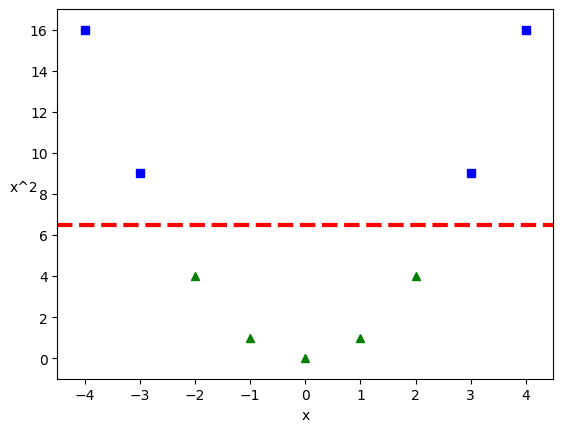

In [179]:
plt.plot(X2[:, 0][y_simple==0], X2[:, 1][y_simple==0], "bs")
plt.plot(X2[:, 0][y_simple==1], X2[:, 1][y_simple==1], "g^")

plt.xlabel("x")
plt.ylabel("x^2", rotation=0)

plt.plot([-4.5, 4.5], [6.5, 6.5], "r--", linewidth=3)
plt.axis([-4.5, 4.5, -1, 17])

### Polynomial Kernel

Adding polynomial features is simple to implement and can work great with all sorts of machine learning algorithms (not just SVMs). That said, at a low polynomial degree this method cannot deal with very complex datasets, and with a high polynomial degree it creates a huge number of features, making the model too slow. Fortunately, when using SVMs you can apply an almost miraculous mathematical technique called the **kernel trick**, that makes it possible to get the same result as if we added many polynomial features, even with a very high degree, without actually having to add them. This means there’s no combinatorial explosion of the number of features. Let’s test it on the moons dataset:

In [180]:
from sklearn.datasets import make_moons

X, y = make_moons(n_samples=100, noise=0.15, random_state=42)

In [181]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

poly_kernel_svm_clf = Pipeline([("scaler", StandardScaler()),
                                ("svm_clf", SVC(kernel="poly", degree=3, coef0=1, C=5))])

poly_kernel_svm_clf.fit(X, y)

Pipeline(steps=[('scaler', StandardScaler()),
                ('svm_clf', SVC(C=5, coef0=1, kernel='poly'))])

In [182]:
def plot_dataset(X, y, axes):
    plt.plot(X[:, 0][y==0], X[:, 1][y==0], "bs")
    plt.plot(X[:, 0][y==1], X[:, 1][y==1], "g^")
    plt.axis(axes)
    plt.grid(True, which='both')
    plt.xlabel("x1")
    plt.ylabel("x2", rotation=0)

In [183]:
def plot_predictions(clf, axes):
    x0s = np.linspace(axes[0], axes[1], 100)
    x1s = np.linspace(axes[2], axes[3], 100)
    x0, x1 = np.meshgrid(x0s, x1s)
    X = np.c_[x0.ravel(), x1.ravel()]
    y_pred = clf.predict(X).reshape(x0.shape)
    y_decision = clf.decision_function(X).reshape(x0.shape)
    plt.contourf(x0, x1, y_pred, cmap=plt.cm.brg, alpha=0.2)
    plt.contourf(x0, x1, y_decision, cmap=plt.cm.brg, alpha=0.1)

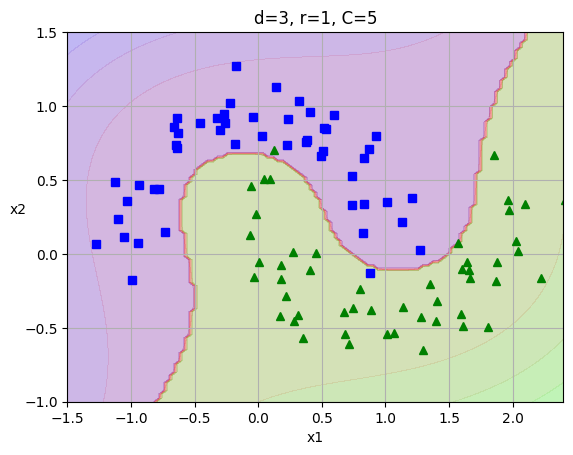

In [184]:
plot_predictions(poly_kernel_svm_clf, [-1.5, 2.4, -1, 1.5])
plot_dataset(X, y, [-1.5, 2.4, -1, 1.5])
plt.title("d=3, r=1, C=5")
plt.show()

The previous code trains a SVM classifier using the polynomial kernel with 3th-degree. If the model is overfitting, we can reduce the polynomial degree, conversely, if it is underfitting, we can try increasing it. The hyperparameter coef0 controls how much the model is influenced by high-degree terms versus
low-degree terms.

### Gaussian RBF Kernel

Another technique to tackle nonlinear problems is to **add features computed using a similarity function**, which measures how much each instance resembles **a particular landmark**. As similarity function we can use the **Gaussian Radial Basis Function (RBF)**, a bell-shaped function varying from 0 (very far away from the landmark) to 1 (at the landmark) controlled by the hyperparameter $\gamma$:

$\phi_\gamma(x,l)= e^{(-\gamma \left\|x-l\right\|^2)}$ 


In [185]:
def gaussian_rbf(x, landmark, gamma):
    return np.exp(-gamma * np.linalg.norm(x - landmark, axis=1)**2)

For example, let’s consider again the a simple 1D non separable dataset, add two landmarks and show the distance of the instances from these landmarks:

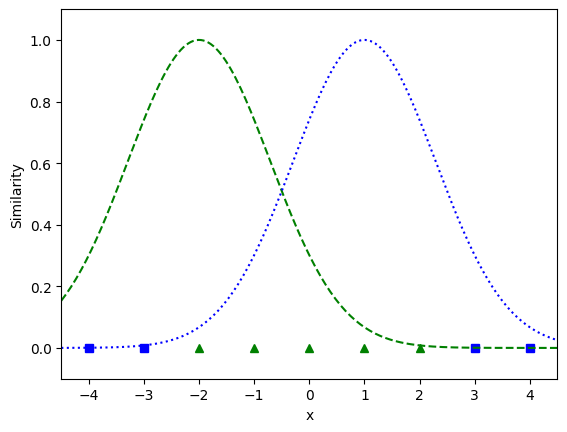

In [186]:
gamma = 0.3

x1s = np.linspace(-4.5, 4.5, 200).reshape(-1, 1)
x2s = gaussian_rbf(x1s, -2, gamma)
x3s = gaussian_rbf(x1s, 1, gamma)

plt.plot(X_simple[:, 0][y_simple==0], np.zeros(4), "bs")
plt.plot(X_simple[:, 0][y_simple==1], np.zeros(5), "g^")
plt.plot(x1s, x2s, "g--")
plt.plot(x1s, x3s, "b:")

plt.xlabel("x")
plt.ylabel("Similarity")

plt.axis([-4.5, 4.5, -0.1, 1.1])

plt.show()

Now we are ready to compute the new features. We consider for each sample the distance from each landmarks and we add a new feature calculated using the similarity function. Then we can plot the transformed dataset (dropping the original features), which is now linearly separable.

In [187]:
XK = np.c_[gaussian_rbf(X_simple, -2, gamma), gaussian_rbf(X_simple, 1, gamma)]
yk = np.array([0, 0, 1, 1, 1, 1, 1, 0, 0])

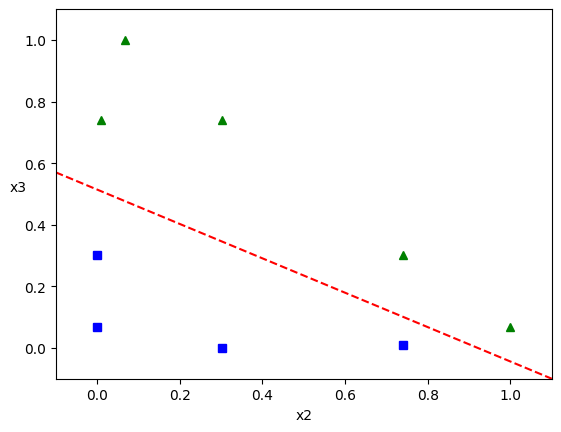

In [188]:
plt.plot(XK[:, 0][yk==0], XK[:, 1][yk==0], "bs")
plt.plot(XK[:, 0][yk==1], XK[:, 1][yk==1], "g^")

plt.xlabel("x2")
plt.ylabel("x3", rotation=0)

plt.plot([-0.1, 1.1], [0.57, -0.1], "r--")
plt.axis([-0.1, 1.1, -0.1, 1.1])

plt.show()

**But how we can to select the landmarks?** The simplest approach is to create **a landmark at the location of each instance** in the dataset. Doing that creates many dimensions and increases the chances that the transformed training set will be linearly separable. The downside is that a training set with $m$ instances and $n$ features gets transformed into a training set with $m$ instances and $m$ features (assuming we drop the original features). If our training set is very large, we end up with an equally large number of features. 

Just like the polynomial features method, the similarity features method can be useful with any machine learning algorithm, but it may be computationally expensive to compute all the additional features (especially on large training sets). Once again **the kernel trick does its SVM magic**, making it possible to obtain a similar result as if you had added many similarity features, but without actually doing so. Let’s try the SVM class with the Gaussian RBF kernel on the moon dataset:

In [189]:
rbf_kernel_svm_clf = Pipeline([("scaler", StandardScaler()),
                               ("svm_clf", SVC(kernel="rbf", gamma=5, C=0.001))])
rbf_kernel_svm_clf.fit(X, y)

Pipeline(steps=[('scaler', StandardScaler()),
                ('svm_clf', SVC(C=0.001, gamma=5))])

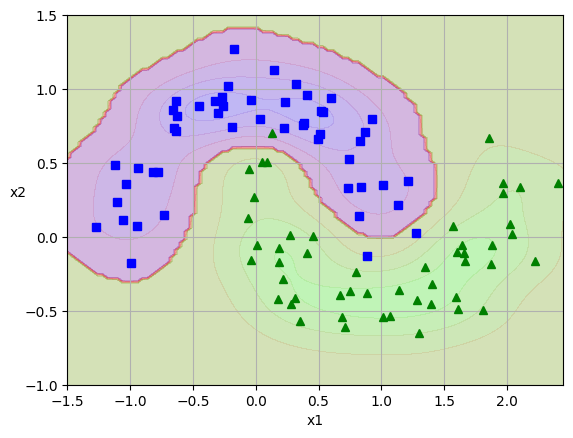

In [190]:
plot_predictions(rbf_kernel_svm_clf, [-1.5, 2.45, -1, 1.5])
plot_dataset(X, y, [-1.5, 2.45, -1, 1.5])

plt.show()

We can modify the hyperparameter $\gamma$ to obtain different results. Increasing $\gamma$ makes the bell-shaped curve narrower, so each instance’s range of influence is smaller and the decision boundary ends up being more irregular, wiggling around individual instances. Conversely, a small $\gamma$ value makes the bellshaped curve wider, instances have a larger range of influence, and the decision boundary ends up smoother. So it acts like a regularization hyperparameter. If a model is overfitting, we should reduce it; if it is underfitting, we should increase it (similar to the C hyperparameter).

In [192]:
gamma_values = 0.1, 1, 10, 100

svm_clfs = []

for gamma in gamma_values:
    rbf_kernel_svm_clf = Pipeline([("scaler", StandardScaler()),
                                   ("svm_clf", SVC(kernel="rbf", gamma=gamma))])
    rbf_kernel_svm_clf.fit(X, y)
    svm_clfs.append(rbf_kernel_svm_clf)

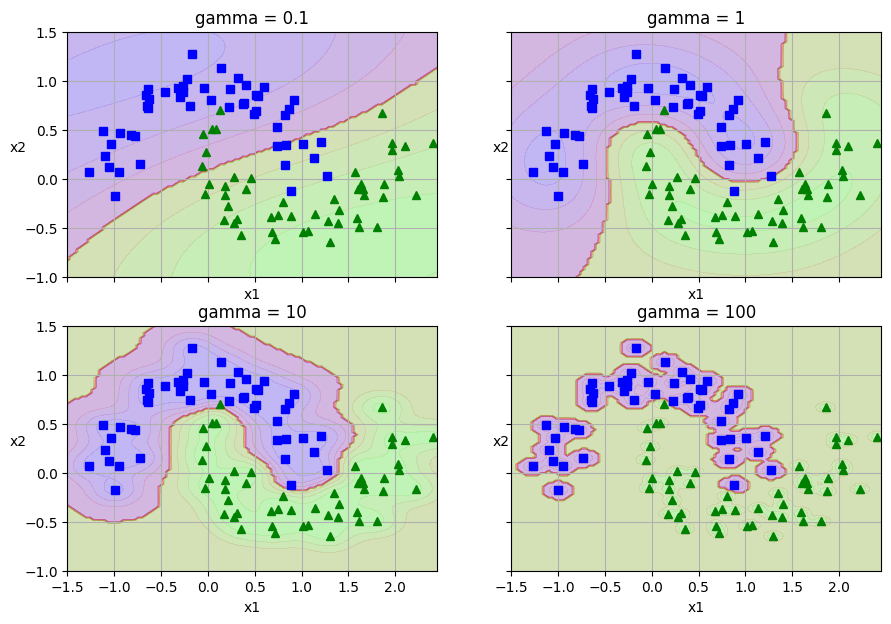

In [195]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10.5, 7), sharex=True, sharey=True)

for i, svm_clf in enumerate(svm_clfs):
    plt.sca(axes[i // 2, i % 2])
    plot_predictions(svm_clf, [-1.5, 2.45, -1, 1.5])
    plot_dataset(X, y, [-1.5, 2.45, -1, 1.5])
    gamma = gamma_values[i]
    plt.title("gamma = {}".format(gamma))

plt.show()

Other kernels exist but are used much more rarely. Some kernels are specialized for specific data structures. String kernels are sometimes used when classifying text documents or DNA sequences (e.g., using the string subsequence kernel or kernels based on the **Levenshtein distance**).

In SKLearni we have two classes: LinearSVC is based on the **liblinear library** and implements an optimized algorithm for linear SVM, but it does not support the kernel trick, but it scales almost linearly with the number of training instances and the number of features. Its training time complexity is roughly $O(m \times n)$. The SVC class is based on the **libsvm library**, which implements an algorithm that supports the kernel trick. The training time complexity is usually between $O(m^2 \times n)$ and $O(m^3 \times n)$. Unfortunately, this means that it gets dreadfully slow when the number of training instances gets large.

## Training

So, making predictions with an SVM classifier is quite straightforward. How training works? This requires **finding the weights vector that makes the street as wide as possible while limiting the number of margin violations**. To make the street large, **we need to make weights smaller**. 

We can visualize this in 2D Let’s define the borders of the street as the
points where the decision function is equal to –1 or +1. In the left plot the weight w is 1, so the points at which w
x = –1 or +1 are x = –1 and +1: therefore the margin’s size is 2. In the right plot the weight is 0.5, so the points at
which w x = –1 or +1 are x = –2 and +2: the margin’s size is 4. So, we need to keep w as small as possible. Note
that the bias term b has no influence on the size of the margin: tweaking it just shifts the margin around, without
affecting its size

## Regression

SVM algorithm is versatile, it also supports linear and nonlinear regression. To use SVMs for regression, the trick is to **tweak the objective**: instead of trying to fit the largest possible street between two classes while limiting margin violations, SVM regression tries **to fit as many
instances as possible on the street**, while limiting margin violations (i.e., instances off the street). The width of the street is controlled by a hyperparameter, $\epsilon$. 

![](images/svm-regression.png)

We can train two linear SVM regressor trained on some random linear data, one with a large margin and the other with a small margin:

In [199]:
m = 50

X = 2 * np.random.rand(m, 1)
y = (4 + 3 * X + np.random.randn(m, 1)).ravel()

In [200]:
from sklearn.svm import LinearSVR

svm_reg_1 = LinearSVR(epsilon=1.5, dual=True, random_state=42)
svm_reg_1.fit(X, y)

LinearSVR(dual=True, epsilon=1.5, random_state=42)

In [202]:
svm_reg_2 = LinearSVR(epsilon=0.5, dual=True, random_state=42)
svm_reg_2.fit(X, y)

LinearSVR(dual=True, epsilon=0.5, random_state=42)

In [210]:
def plot_svm_regression(svm_reg, X, y, axes):
    x1s = np.linspace(axes[0], axes[1], 100).reshape(100, 1)
    y_pred = svm_reg.predict(x1s)
    
    plt.plot(x1s, y_pred, "k-", label=r"$\hat{y}$")
    plt.plot(x1s, y_pred + svm_reg.epsilon, "k--")
    plt.plot(x1s, y_pred - svm_reg.epsilon, "k--")
    
    plt.plot(X, y, "bo")
    
    plt.xlabel(r"x")
    plt.axis(axes)

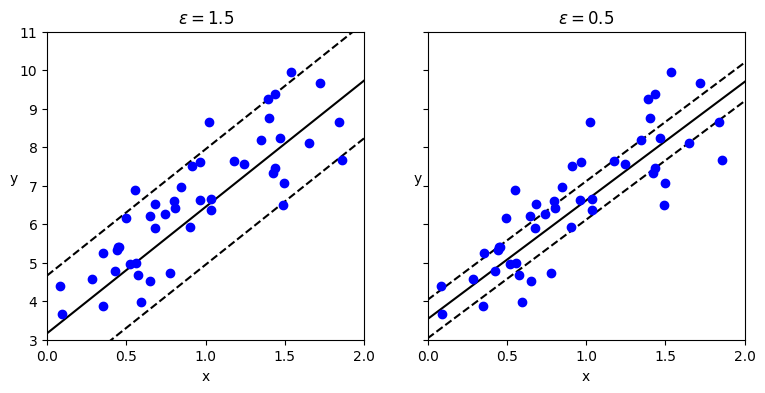

In [211]:
fig, axes = plt.subplots(ncols=2, figsize=(9, 4), sharey=True)

plt.sca(axes[0])
plot_svm_regression(svm_reg_1, X, y, [0, 2, 3, 11])
plt.title(r"$\epsilon = {}$".format(svm_reg_1.epsilon))
plt.ylabel("y", rotation=0)

plt.sca(axes[1])
plot_svm_regression(svm_reg_2, X, y, [0, 2, 3, 11])
plt.title(r"$\epsilon = {}$".format(svm_reg_2.epsilon))
plt.ylabel("y", rotation=0)

plt.show()

To tackle nonlinear regression tasks, we can use a kernelized SVM model. We can try on  a random quadratic training set, using a second-degree polynomial kernel:

In [212]:
m = 100

X = 2 * np.random.rand(m, 1) - 1
y = (0.2 + 0.1 * X + 0.5 * X**2 + np.random.randn(m, 1)/10).ravel()

In [213]:
from sklearn.svm import SVR

svm_poly_reg = SVR(kernel="poly", degree=2, C=100, epsilon=0.1, gamma="scale")
svm_poly_reg.fit(X, y)

SVR(C=100, degree=2, kernel='poly')

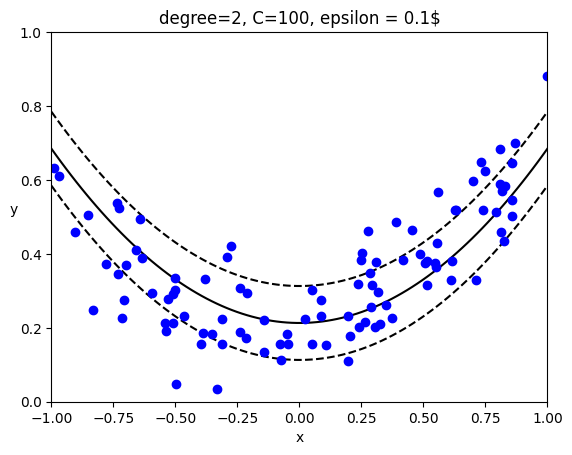

In [214]:
plot_svm_regression(svm_poly_reg, X, y, [-1, 1, 0, 1])
plt.title("degree={}, C={}, epsilon = {}$".format(svm_poly_reg.degree, svm_poly_reg.C, svm_poly_reg.epsilon))
plt.ylabel("y", rotation=0)

plt.show()

## Exercise

**1 - Train a LinearSVC on a linearly separable dataset (using the Iris dataset). Then train an SVC and a SGDClassifier on the same dataset. See if you can get them to produce roughly
the same model**

Let's use the Iris dataset: the Iris Setosa and Iris Versicolor classes are linearly separable.

In [44]:
from sklearn import datasets

iris = datasets.load_iris()
X = iris["data"][:, (2, 3)]  # petal length, petal width
y = iris["target"]

setosa_or_versicolor = (y == 0) | (y == 1)
X = X[setosa_or_versicolor]
y = y[setosa_or_versicolor]

In [45]:
from sklearn.svm import SVC, LinearSVC
from sklearn.linear_model import SGDClassifier
from sklearn.preprocessing import StandardScaler

C = 5
alpha = 1 / (C * len(X))

lin_clf = LinearSVC(loss="hinge", C=C, random_state=42)
svm_clf = SVC(kernel="linear", C=C)
sgd_clf = SGDClassifier(loss="hinge", learning_rate="constant", eta0=0.001, alpha=alpha,
                        max_iter=1000, tol=1e-3, random_state=42)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

lin_clf.fit(X_scaled, y)
svm_clf.fit(X_scaled, y)
sgd_clf.fit(X_scaled, y)

print("LinearSVC:                   ", lin_clf.intercept_, lin_clf.coef_)
print("SVC:                         ", svm_clf.intercept_, svm_clf.coef_)
print("SGDClassifier(alpha={:.5f}):".format(sgd_clf.alpha), sgd_clf.intercept_, sgd_clf.coef_)

LinearSVC:                    [0.28474532] [[1.05364923 1.09903601]]
SVC:                          [0.31896852] [[1.1203284  1.02625193]]
SGDClassifier(alpha=0.00200): [0.117] [[0.77666262 0.72787608]]


Let's plot the decision boundaries of these three models:

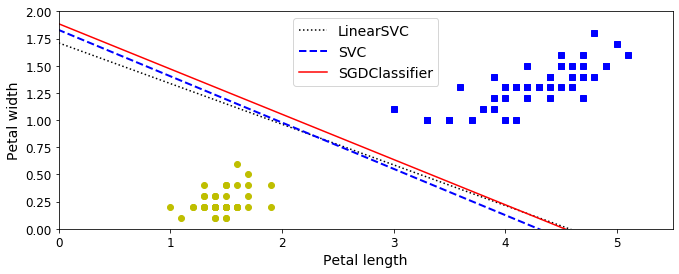

In [46]:
# Compute the slope and bias of each decision boundary
w1 = -lin_clf.coef_[0, 0]/lin_clf.coef_[0, 1]
b1 = -lin_clf.intercept_[0]/lin_clf.coef_[0, 1]
w2 = -svm_clf.coef_[0, 0]/svm_clf.coef_[0, 1]
b2 = -svm_clf.intercept_[0]/svm_clf.coef_[0, 1]
w3 = -sgd_clf.coef_[0, 0]/sgd_clf.coef_[0, 1]
b3 = -sgd_clf.intercept_[0]/sgd_clf.coef_[0, 1]

# Transform the decision boundary lines back to the original scale
line1 = scaler.inverse_transform([[-10, -10 * w1 + b1], [10, 10 * w1 + b1]])
line2 = scaler.inverse_transform([[-10, -10 * w2 + b2], [10, 10 * w2 + b2]])
line3 = scaler.inverse_transform([[-10, -10 * w3 + b3], [10, 10 * w3 + b3]])

# Plot all three decision boundaries
plt.figure(figsize=(11, 4))
plt.plot(line1[:, 0], line1[:, 1], "k:", label="LinearSVC")
plt.plot(line2[:, 0], line2[:, 1], "b--", linewidth=2, label="SVC")
plt.plot(line3[:, 0], line3[:, 1], "r-", label="SGDClassifier")
plt.plot(X[:, 0][y==1], X[:, 1][y==1], "bs") # label="Iris versicolor"
plt.plot(X[:, 0][y==0], X[:, 1][y==0], "yo") # label="Iris setosa"
plt.xlabel("Petal length", fontsize=14)
plt.ylabel("Petal width", fontsize=14)
plt.legend(loc="upper center", fontsize=14)
plt.axis([0, 5.5, 0, 2])

plt.show()

Close enough!

**2 - Train an SVM classifier on the MNIST dataset. Since SVM classifiers are binary classifiers, you will need to use one-versus-the-rest to classify all 10 digits. You may want to tune the hyperparameters using small validation sets to speed up the process. What accuracy can you reach?**

First, let's load the dataset and split it into a training set and a test set. We could use `train_test_split()` but people usually just take the first 60,000 instances for the training set, and the last 10,000 instances for the test set (this makes it possible to compare your model's performance with others): 

In [47]:
from sklearn.datasets import fetch_openml
mnist = fetch_openml('mnist_784', version=1, cache=True)

X = mnist["data"]
y = mnist["target"].astype(np.uint8)

X_train = X[:60000]
y_train = y[:60000]
X_test = X[60000:]
y_test = y[60000:]

Many training algorithms are sensitive to the order of the training instances, so it's generally good practice to shuffle them first. However, the dataset is already shuffled, so we do not need to do it.

Let's start simple, with a linear SVM classifier. It will automatically use the One-vs-All (also called One-vs-the-Rest, OvR) strategy, so there's nothing special we need to do. Easy!

**Warning**: this may take a few minutes depending on your hardware.

In [48]:
lin_clf = LinearSVC(random_state=42)
lin_clf.fit(X_train, y_train)

/Users/ageron/miniconda3/envs/tf2b/lib/python3.7/site-packages/sklearn/svm/base.py:931: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  "the number of iterations.", ConvergenceWarning)


LinearSVC(C=1.0, class_weight=None, dual=True, fit_intercept=True,
     intercept_scaling=1, loss='squared_hinge', max_iter=1000,
     multi_class='ovr', penalty='l2', random_state=42, tol=0.0001,
     verbose=0)

Let's make predictions on the training set and measure the accuracy (we don't want to measure it on the test set yet, since we have not selected and trained the final model yet):

In [49]:
from sklearn.metrics import accuracy_score

y_pred = lin_clf.predict(X_train)
accuracy_score(y_train, y_pred)

0.895

Okay, 89.5% accuracy on MNIST is pretty bad. This linear model is certainly too simple for MNIST, but perhaps we just needed to scale the data first:

In [50]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.astype(np.float32))
X_test_scaled = scaler.transform(X_test.astype(np.float32))

**Warning**: this may take a few minutes depending on your hardware.

In [51]:
lin_clf = LinearSVC(random_state=42)
lin_clf.fit(X_train_scaled, y_train)

/Users/ageron/miniconda3/envs/tf2b/lib/python3.7/site-packages/sklearn/svm/base.py:931: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  "the number of iterations.", ConvergenceWarning)


LinearSVC(C=1.0, class_weight=None, dual=True, fit_intercept=True,
     intercept_scaling=1, loss='squared_hinge', max_iter=1000,
     multi_class='ovr', penalty='l2', random_state=42, tol=0.0001,
     verbose=0)

In [52]:
y_pred = lin_clf.predict(X_train_scaled)
accuracy_score(y_train, y_pred)

0.92105

That's much better (we cut the error rate by about 25%), but still not great at all for MNIST. If we want to use an SVM, we will have to use a kernel. Let's try an `SVC` with an RBF kernel (the default).

**Note**: to be future-proof we set `gamma="scale"` since it will be the default value in Scikit-Learn 0.22.

In [53]:
svm_clf = SVC(gamma="scale")
svm_clf.fit(X_train_scaled[:10000], y_train[:10000])

SVC(C=1.0, cache_size=200, class_weight=None, coef0=0.0,
  decision_function_shape='ovr', degree=3, gamma='scale', kernel='rbf',
  max_iter=-1, probability=False, random_state=None, shrinking=True,
  tol=0.001, verbose=False)

In [54]:
y_pred = svm_clf.predict(X_train_scaled)
accuracy_score(y_train, y_pred)

0.9455333333333333

That's promising, we get better performance even though we trained the model on 6 times less data. Let's tune the hyperparameters by doing a randomized search with cross validation. We will do this on a small dataset just to speed up the process:

In [55]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import reciprocal, uniform

param_distributions = {"gamma": reciprocal(0.001, 0.1), "C": uniform(1, 10)}
rnd_search_cv = RandomizedSearchCV(svm_clf, param_distributions, n_iter=10, verbose=2, cv=3)
rnd_search_cv.fit(X_train_scaled[:1000], y_train[:1000])

Fitting 3 folds for each of 10 candidates, totalling 30 fits
[CV] C=4.205364371116072, gamma=0.0020363543195523162 ................


[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.


[CV] . C=4.205364371116072, gamma=0.0020363543195523162, total=   0.6s
[CV] C=4.205364371116072, gamma=0.0020363543195523162 ................


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.9s remaining:    0.0s


[CV] . C=4.205364371116072, gamma=0.0020363543195523162, total=   0.6s
[CV] C=4.205364371116072, gamma=0.0020363543195523162 ................
[CV] . C=4.205364371116072, gamma=0.0020363543195523162, total=   0.6s
[CV] C=7.988626913672013, gamma=0.0017374050727190405 ................
[CV] . C=7.988626913672013, gamma=0.0017374050727190405, total=   0.6s
[CV] C=7.988626913672013, gamma=0.0017374050727190405 ................
[CV] . C=7.988626913672013, gamma=0.0017374050727190405, total=   0.6s
[CV] C=7.988626913672013, gamma=0.0017374050727190405 ................
[CV] . C=7.988626913672013, gamma=0.0017374050727190405, total=   0.6s
[CV] C=5.85175909599865, gamma=0.01842788363564703 ...................
[CV] .... C=5.85175909599865, gamma=0.01842788363564703, total=   0.7s
[CV] C=5.85175909599865, gamma=0.01842788363564703 ...................
[CV] .... C=5.85175909599865, gamma=0.01842788363564703, total=   0.7s
[CV] C=5.85175909599865, gamma=0.01842788363564703 ...................
[CV] .

[Parallel(n_jobs=1)]: Done  30 out of  30 | elapsed:   28.9s finished
/Users/ageron/miniconda3/envs/tf2b/lib/python3.7/site-packages/sklearn/model_selection/_search.py:842: DeprecationWarning: The default of the `iid` parameter will change from True to False in version 0.22 and will be removed in 0.24. This will change numeric results when test-set sizes are unequal.
  DeprecationWarning)


RandomizedSearchCV(cv=3, error_score='raise-deprecating',
          estimator=SVC(C=1.0, cache_size=200, class_weight=None, coef0=0.0,
  decision_function_shape='ovr', degree=3, gamma='scale', kernel='rbf',
  max_iter=-1, probability=False, random_state=None, shrinking=True,
  tol=0.001, verbose=False),
          fit_params=None, iid='warn', n_iter=10, n_jobs=None,
          param_distributions={'gamma': <scipy.stats._distn_infrastructure.rv_frozen object at 0x7f9850502d90>, 'C': <scipy.stats._distn_infrastructure.rv_frozen object at 0x7f98b046a550>},
          pre_dispatch='2*n_jobs', random_state=None, refit=True,
          return_train_score='warn', scoring=None, verbose=2)

In [56]:
rnd_search_cv.best_estimator_

SVC(C=7.988626913672013, cache_size=200, class_weight=None, coef0=0.0,
  decision_function_shape='ovr', degree=3, gamma=0.0017374050727190405,
  kernel='rbf', max_iter=-1, probability=False, random_state=None,
  shrinking=True, tol=0.001, verbose=False)

In [57]:
rnd_search_cv.best_score_

0.86

This looks pretty low but remember we only trained the model on 1,000 instances. Let's retrain the best estimator on the whole training set (run this at night, it will take hours):

In [58]:
rnd_search_cv.best_estimator_.fit(X_train_scaled, y_train)

SVC(C=7.988626913672013, cache_size=200, class_weight=None, coef0=0.0,
  decision_function_shape='ovr', degree=3, gamma=0.0017374050727190405,
  kernel='rbf', max_iter=-1, probability=False, random_state=None,
  shrinking=True, tol=0.001, verbose=False)

In [59]:
y_pred = rnd_search_cv.best_estimator_.predict(X_train_scaled)
accuracy_score(y_train, y_pred)

0.9995

Ah, this looks good! Let's select this model. Now we can test it on the test set:

In [60]:
y_pred = rnd_search_cv.best_estimator_.predict(X_test_scaled)
accuracy_score(y_test, y_pred)

0.9713

Not too bad, but apparently the model is overfitting slightly. It's tempting to tweak the hyperparameters a bit more (e.g. decreasing `C` and/or `gamma`), but we would run the risk of overfitting the test set. Other people have found that the hyperparameters `C=5` and `gamma=0.005` yield even better performance (over 98% accuracy). By running the randomized search for longer and on a larger part of the training set, you may be able to find this as well.

**3 - Train an SVM regressor on the California housing dataset**

Let's load the dataset using Scikit-Learn's `fetch_california_housing()` function:

In [61]:
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing()
X = housing["data"]
y = housing["target"]

Split it into a training set and a test set:

In [62]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Don't forget to scale the data:

In [63]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Let's train a simple `LinearSVR` first:

In [64]:
from sklearn.svm import LinearSVR

lin_svr = LinearSVR(random_state=42)
lin_svr.fit(X_train_scaled, y_train)

/Users/ageron/miniconda3/envs/tf2b/lib/python3.7/site-packages/sklearn/svm/base.py:931: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  "the number of iterations.", ConvergenceWarning)


LinearSVR(C=1.0, dual=True, epsilon=0.0, fit_intercept=True,
     intercept_scaling=1.0, loss='epsilon_insensitive', max_iter=1000,
     random_state=42, tol=0.0001, verbose=0)

Let's see how it performs on the training set:

In [65]:
from sklearn.metrics import mean_squared_error

y_pred = lin_svr.predict(X_train_scaled)
mse = mean_squared_error(y_train, y_pred)
mse

0.954517044073374

Let's look at the RMSE:

In [66]:
np.sqrt(mse)

0.976993881287582

In this training set, the targets are tens of thousands of dollars. The RMSE gives a rough idea of the kind of error you should expect (with a higher weight for large errors): so with this model we can expect errors somewhere around $10,000. Not great. Let's see if we can do better with an RBF Kernel. We will use randomized search with cross validation to find the appropriate hyperparameter values for `C` and `gamma`:

In [67]:
from sklearn.svm import SVR
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import reciprocal, uniform

param_distributions = {"gamma": reciprocal(0.001, 0.1), "C": uniform(1, 10)}
rnd_search_cv = RandomizedSearchCV(SVR(), param_distributions, n_iter=10, verbose=2, cv=3, random_state=42)
rnd_search_cv.fit(X_train_scaled, y_train)

[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.


Fitting 3 folds for each of 10 candidates, totalling 30 fits
[CV] C=4.745401188473625, gamma=0.07969454818643928 ..................
[CV] ... C=4.745401188473625, gamma=0.07969454818643928, total=   5.4s
[CV] C=4.745401188473625, gamma=0.07969454818643928 ..................


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    7.3s remaining:    0.0s


[CV] ... C=4.745401188473625, gamma=0.07969454818643928, total=   5.5s
[CV] C=4.745401188473625, gamma=0.07969454818643928 ..................
[CV] ... C=4.745401188473625, gamma=0.07969454818643928, total=   5.5s
[CV] C=8.31993941811405, gamma=0.015751320499779724 ..................
[CV] ... C=8.31993941811405, gamma=0.015751320499779724, total=   5.3s
[CV] C=8.31993941811405, gamma=0.015751320499779724 ..................
[CV] ... C=8.31993941811405, gamma=0.015751320499779724, total=   5.2s
[CV] C=8.31993941811405, gamma=0.015751320499779724 ..................
[CV] ... C=8.31993941811405, gamma=0.015751320499779724, total=   5.1s
[CV] C=2.560186404424365, gamma=0.002051110418843397 .................
[CV] .. C=2.560186404424365, gamma=0.002051110418843397, total=   4.6s
[CV] C=2.560186404424365, gamma=0.002051110418843397 .................
[CV] .. C=2.560186404424365, gamma=0.002051110418843397, total=   4.6s
[CV] C=2.560186404424365, gamma=0.002051110418843397 .................
[CV] .

[Parallel(n_jobs=1)]: Done  30 out of  30 | elapsed:  3.5min finished


RandomizedSearchCV(cv=3, error_score='raise-deprecating',
          estimator=SVR(C=1.0, cache_size=200, coef0=0.0, degree=3, epsilon=0.1,
  gamma='auto_deprecated', kernel='rbf', max_iter=-1, shrinking=True,
  tol=0.001, verbose=False),
          fit_params=None, iid='warn', n_iter=10, n_jobs=None,
          param_distributions={'gamma': <scipy.stats._distn_infrastructure.rv_frozen object at 0x12fc2e390>, 'C': <scipy.stats._distn_infrastructure.rv_frozen object at 0x12fc2eac8>},
          pre_dispatch='2*n_jobs', random_state=42, refit=True,
          return_train_score='warn', scoring=None, verbose=2)

In [68]:
rnd_search_cv.best_estimator_

SVR(C=4.745401188473625, cache_size=200, coef0=0.0, degree=3, epsilon=0.1,
  gamma=0.07969454818643928, kernel='rbf', max_iter=-1, shrinking=True,
  tol=0.001, verbose=False)

Now let's measure the RMSE on the training set:

In [69]:
y_pred = rnd_search_cv.best_estimator_.predict(X_train_scaled)
mse = mean_squared_error(y_train, y_pred)
np.sqrt(mse)

0.5727524770785359

Looks much better than the linear model. Let's select this model and evaluate it on the test set:

In [70]:
y_pred = rnd_search_cv.best_estimator_.predict(X_test_scaled)
mse = mean_squared_error(y_test, y_pred)
np.sqrt(mse)

0.5929168385528734